In [2]:
WIDTH = 9
HEIGHT = 9
NUM_AGENTS = 4

In [3]:
import sys
sys.path.append('../../..')
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


In [4]:
df_val: pd.DataFrame = pickle.load(open(f'predicted_trajectory_values_{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}.pkl', 'rb'))


In [5]:
df_ir: pd.DataFrame = pickle.load(open(f'predicted_trajectory_ir_{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}.pkl', 'rb'))

In [6]:
print(df_ir.keys())

Index(['state_index', 'timestep', 'state_object', 'true_reward_A0',
       'pred_reward_A0', 'error_A0', 'true_reward_A1', 'pred_reward_A1',
       'error_A1', 'true_reward_A2', 'pred_reward_A2', 'error_A2',
       'true_reward_A3', 'pred_reward_A3', 'error_A3', 'total_reward_error'],
      dtype='object')


In [9]:
# Assuming df_ir is your dataframe
agent_col = 'A0'  # Can change to 'A1', 'A2', etc.
true_col = f'true_reward_{agent_col}'
pred_col = f'pred_reward_{agent_col}'

# --- 1. Separate the Data ---
# Mask for states where the true reward is effectively 0
zero_mask = np.abs(df_ir[true_col]) < 1e-6
# Mask for states where there is an actual reward signal
nonzero_mask = ~zero_mask

df_zero = df_ir[zero_mask]
df_nonzero = df_ir[nonzero_mask]

print(f"--- Analysis for Agent {agent_col} ---")
print(f"Total samples: {len(df_ir)}")
print(f"Zero-reward samples (Noise check): {len(df_zero)} ({len(df_zero)/len(df_ir)*100:.1f}%)")
print(f"Non-zero reward samples (Signal check): {len(df_nonzero)}\n")

# --- 2. Calculate MAE for Zero Rewards (Noise Level) ---
# We only care about Absolute Error here because Relative Error is undefined.
if len(df_zero) > 0:
    noise_mae = np.abs(df_zero[pred_col] - df_zero[true_col]).mean()
    noise_std = np.abs(df_zero[pred_col] - df_zero[true_col]).std()
    print(f"Case 1: True Reward = 0 (Noise Analysis)")
    print(f"  Metric: Mean Absolute Error (MAE)")
    print(f"  Result: {noise_mae:.6f} ± {noise_std:.6f}")
    print(f"  Interpretation: When nothing happens, the model predicts ~{noise_mae:.4f}.")

# --- 3. Calculate Relative Error for Non-Zero Rewards (Signal Accuracy) ---
# Here relative error makes sense because there is a signal to measure against.
if len(df_nonzero) > 0:
    # Calculate absolute error first
    abs_err = np.abs(df_nonzero[pred_col] - df_nonzero[true_col])
    # Calculate relative error (no epsilon needed really, but good for safety)
    rel_err = abs_err / (np.abs(df_nonzero[true_col]) + 1e-9)
    
    print(f"\nCase 2: True Reward != 0 (Signal Analysis)")
    print(f"  Metric: Relative Error (|pred - true| / |true|)")
    print(f"  Result: {rel_err.mean()*100:.2f}% ± {rel_err.std()*100:.2f}%")
    print(f"  (Absolute MAE for these states: {abs_err.mean():.4f})")
    
    # Optional: Peek at a few examples to convince yourself
    print("\n  Sample Predictions (True vs Pred):")
    sample = df_nonzero[[true_col, pred_col]].head(5)
    print(sample.to_string(index=False))

--- Analysis for Agent A0 ---
Total samples: 800000
Zero-reward samples (Noise check): 538297 (67.3%)
Non-zero reward samples (Signal check): 261703

Case 1: True Reward = 0 (Noise Analysis)
  Metric: Mean Absolute Error (MAE)
  Result: 0.013815 ± 0.016625
  Interpretation: When nothing happens, the model predicts ~0.0138.

Case 2: True Reward != 0 (Signal Analysis)
  Metric: Relative Error (|pred - true| / |true|)
  Result: 10.28% ± 12.08%
  (Absolute MAE for these states: 0.0650)

  Sample Predictions (True vs Pred):
 true_reward_A0  pred_reward_A0
       0.292328        0.271281
      -1.000000       -1.025407
       0.480506        0.422462
       0.558482        0.556922
       0.633184        0.647091


In [ ]:
print(f"average error agent 0: {df_ir['error_A0'].mean()}")
print(f"average true reward agent 0: {df_ir['true_reward_A0'].mean()}")
print(f"average error agent 1: {df_ir['error_A1'].mean()}")
print(f"average true reward agent 1: {df_ir['true_reward_A1'].mean()}")


average error agent 0: 0.03056315340131824
average true reward agent 0: 0.08143995761923348
average error agent 1: 0.019127606492294832
average true reward agent 1: 0.08202597684371368


In [ ]:
relative_errs = []
for index, row in tqdm(df_ir.iterrows(), total=len(df_ir)):
    pred = row['pred_reward_A0']
    true = row['true_reward_A0']
    error = abs(pred - true)
    relative_err = error / (abs(true) + 1e-8)
    relative_errs.append(relative_err)
relative_errs = np.array(relative_errs)
print(f"avg relative err agent 0 :", np.mean(relative_errs))

100%|██████████| 800000/800000 [00:29<00:00, 26847.28it/s]

avg relative err agent 0 : 929589.9130731734


In [ ]:
print(df_val.keys())

Index(['state_index', 'timestep', 'centralized_team_value',
       'decentralized_team_value', 'error', 'centralized - decentralized',
       'state_object'],
      dtype='object')


In [ ]:
print(f"mean error: {df_val['error'].mean()}")
print(f"centralized mean team value: {df_val['centralized_team_value'].mean()}")
print(f"decentralized mean team value: {df_val['decentralized_team_value'].mean()}")

mean error: 1.058723644414246
centralized mean team value: 32.80049069618463
decentralized mean team value: 32.06186362636655


In [ ]:
# Ensure DataFrames align perfectly before merging
assert len(df_val) == len(df_ir), "DataFrames length mismatch!"
# Check first and last state objects to ensure trajectory alignment
assert df_val.iloc[0]['state_object'] == df_ir.iloc[0]['state_object'], "Start state mismatch!"
assert df_val.iloc[-1]['state_object'] == df_ir.iloc[-1]['state_object'], "End state mismatch!"
for index, row in tqdm(df_val.iterrows(), total=len(df_val)):
    assert df_val.loc[index, 'state_object'] == df_ir.loc[index, 'state_object'], f"State mismatch at index {index}!"

100%|██████████| 800000/800000 [00:58<00:00, 13785.47it/s]


In [ ]:

print("✅ Verification successful: DataFrames align.")

# --- Step 2: Select Columns and Merge ---
# We want these specific columns from the IR DataFrame
ir_cols = [
    'true_reward_A0', 'pred_reward_A0', 'error_A0',
    'true_reward_A1', 'pred_reward_A1', 'error_A1',
    'total_reward_error'
]

# Merge on index (axis=1)
df_combined = pd.concat([df_val, df_ir[ir_cols]], axis=1)

# Define the list of columns we want to display in our report later
display_cols = [
    'timestep',
    'centralized_team_value', 'decentralized_team_value', 'error', # Value Info
    'true_reward_A0', 'pred_reward_A0', 'error_A0',                # Agent 0 Reward Info
    'true_reward_A1', 'pred_reward_A1', 'error_A1'                 # Agent 1 Reward Info
]

print("Data merged. Ready for analysis.")

In [ ]:
N_STATES = 10  # Number of states to analyze for each group

# Sort by Value Error (descending)
df_sorted = df_combined.sort_values(by='error', ascending=False)

# Get the N Worst (Highest Value Error)
worst_states = df_sorted.head(N_STATES)

# Get the N Best (Lowest Value Error)
best_states = df_sorted.tail(N_STATES)

# --- Helper Function to Print Analysis ---
def analyze_subset(subset_df, title):
    print(f"\n{'='*30} {title} {'='*30}")
    # 1. Print the Data Table
    print(subset_df[display_cols].to_string(index=False))

# --- Run the Analysis ---

analyze_subset(worst_states, "WORST Value Predictions (Highest Error)")
analyze_subset(best_states, "BEST Value Predictions (Lowest Error)")
# --- Optional: Visualizing the #1 Worst State ---



============================== WORST Value Predictions (Highest Error) ==============================
 timestep  centralized_team_value  decentralized_team_value    error  true_reward_A0  pred_reward_A0  error_A0  true_reward_A1  pred_reward_A1  error_A1
 150842.5               33.196003                 27.445183 5.750820        0.672473        0.655208  0.017265       -1.000000       -0.991268  0.008732
 150841.5               33.184914                 27.528558 5.656356        0.365488        0.363131  0.002357        0.817256        0.748802  0.068454
 156064.5               33.526112                 27.871643 5.654469        0.612574        0.542669  0.069905       -1.000000       -0.990919  0.009081
 307593.5               33.306156                 27.685714 5.620442        0.690282        0.366621  0.323661        0.436573        0.393786  0.042787
 264387.5               34.118858                 28.564173 5.554686        0.196806        0.034387  0.162419       -1.000000      

In [ ]:
for idx, row in worst_states.iterrows():
    print(f"\n{'='*30} VISUALIZING WORST STATE at Timestep {row['timestep']} {'='*30}")
    print(row['state_object'])


============================== VISUALIZING WORST STATE at Timestep 150842.5 ==============================
--- Empty State (Grid: 9x9) ---

--- Agent Locations ---
  Agent 0: (2, 5)
  Agent 1: (4, 4)
  Agent 2: (3, 5)
  Agent 3: (1, 4)

--- Agents (Count) ---
. . . . . . . . .
. . . . 1 . . . .
. . . . . 1 . . .
. . . . . 1 . . .
. . . . 1 . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .

--- Apples (Count) ---
1 . . 1 . . . . 1
. . . . . . . . .
. . . . 1 . . . 1
. . . . . . . . .
. . . . 1 . . . 1
. . . . . . . 1 .
1 . . . . . . . .
. . . 1 . . . . .
1 . . 1 . . . . .

============================== VISUALIZING WORST STATE at Timestep 150841.5 ==============================
--- Empty State (Grid: 9x9) ---

--- Agent Locations ---
  Agent 0: (2, 5)
  Agent 1: (5, 4)
  Agent 2: (3, 5)
  Agent 3: (1, 4)

--- Agents (Count) ---
. . . . . . . . .
. . . . 1 . . . .
. . . . . 1 . . .
. . . . . 1 . . .
. . . . . . . . .
. . . . 1 . . . .
. . . . . . . . .
. . 

In [ ]:
for idx, row in reversed(list(best_states.iterrows())):
    print(f"\n{'='*30} VISUALIZING BEST STATE at Timestep {row['timestep']} {'='*30}")
    print(row['state_object'])


============================== VISUALIZING BEST STATE at Timestep 371921.5 ==============================
--- Empty State (Grid: 9x9) ---

--- Agent Locations ---
  Agent 0: (7, 5)
  Agent 1: (3, 0)
  Agent 2: (3, 5)
  Agent 3: (3, 3)

--- Agents (Count) ---
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
1 . . 1 . 1 . . .
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
. . . . . 1 . . .
. . . . . . . . .

--- Apples (Count) ---
1 . . . 1 . . . .
. . . . . 1 1 . 1
. . . . . . . . .
. 1 . . . . . 1 .
. . 1 . . . . . .
. . 1 . . . 1 . .
1 . . . . . . . .
. . . . . . . . .
. 1 . . . . . . .

============================== VISUALIZING BEST STATE at Timestep 288310.5 ==============================
--- Empty State (Grid: 9x9) ---

--- Agent Locations ---
  Agent 0: (3, 0)
  Agent 1: (6, 6)
  Agent 2: (6, 1)
  Agent 3: (3, 3)

--- Agents (Count) ---
. . . . . . . . .
. . . . . . . . .
. . . . . . . . .
1 . . 1 . . . . .
. . . . . . . . .
. . . . . . . . .
. 1 . . . . 1 . .
. . . 

Generating plots for N=10...
✅ Verified: States match perfectly for all 10 entries in 'Top 10 WORST Value Predictions'.


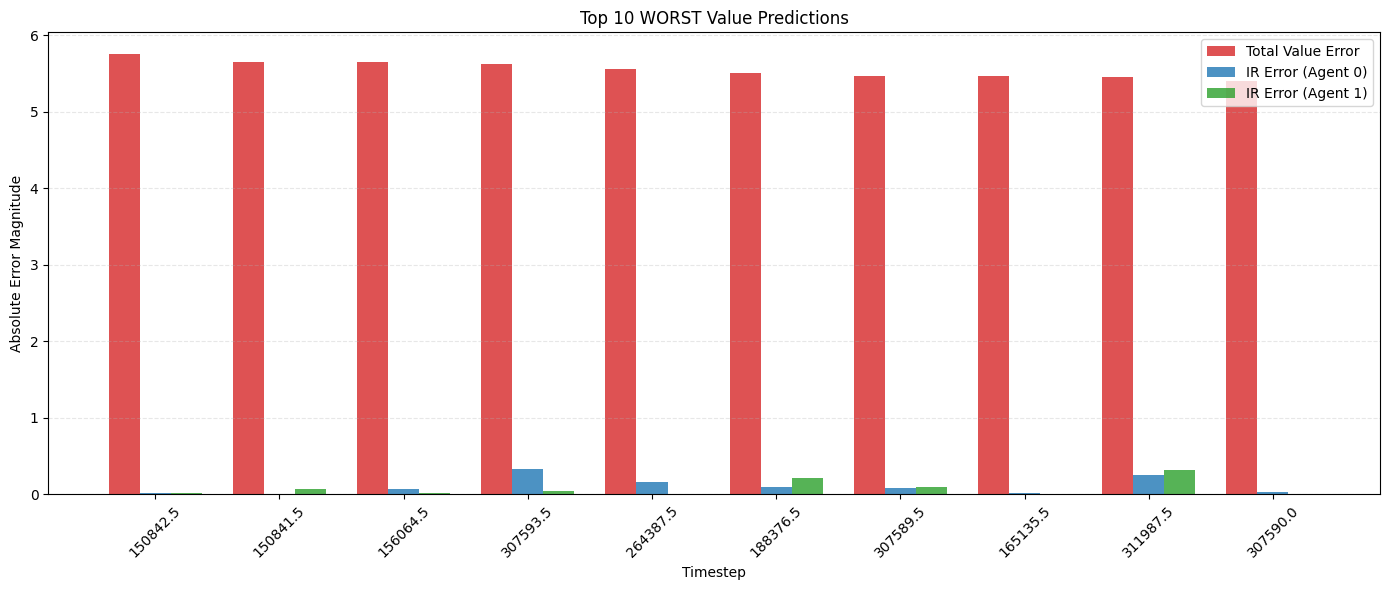

✅ Verified: States match perfectly for all 10 entries in 'Top 10 BEST Value Predictions'.


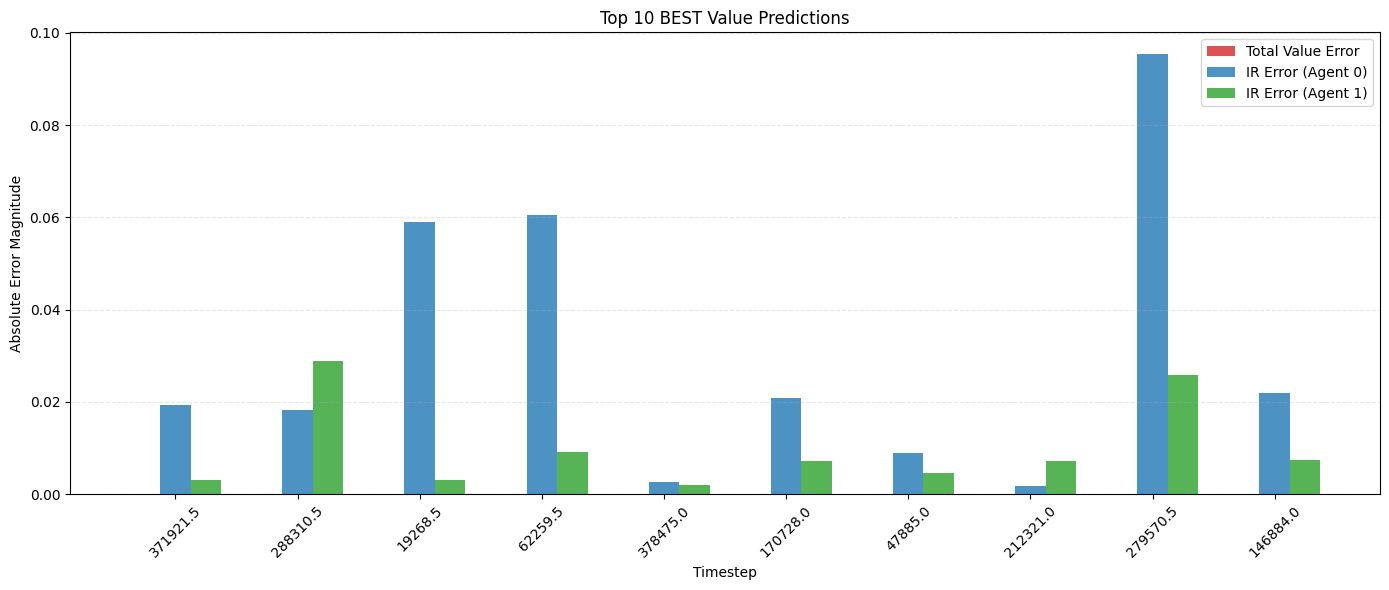

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def verify_and_plot(subset_df, title):
    """
    Verifies state consistency and plots Value Error vs IR Errors.
    """
    # --- 1. Rigorous Verification ---
    # We iterate through the specific indices of this subset
    subset_indices = subset_df.index
    
    for idx in subset_indices:
        # Retrieve the state object from the ORIGINAL source dataframes
        state_from_val = df_val.loc[idx]['state_object']
        state_from_ir = df_ir.loc[idx]['state_object']
        
        # Check that they are the exact same object or at least equal
        if state_from_val != state_from_ir:
            raise ValueError(f"CRITICAL FAILURE: State mismatch at index {idx}!")
            
    print(f"✅ Verified: States match perfectly for all {len(subset_df)} entries in '{title}'.")

    # --- 2. Plotting ---
    timesteps = subset_df['timestep'].values
    
    # Data to plot
    value_errors = subset_df['error'].values
    ir_errors_a0 = subset_df['error_A0'].values
    ir_errors_a1 = subset_df['error_A1'].values
    
    x = np.arange(len(timesteps))  # Label locations
    width = 0.25  # Width of the bars

    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Create grouped bars
    rects1 = ax.bar(x - width, value_errors, width, label='Total Value Error', color='#d62728', alpha=0.8)
    rects2 = ax.bar(x, ir_errors_a0, width, label='IR Error (Agent 0)', color='#1f77b4', alpha=0.8)
    rects3 = ax.bar(x + width, ir_errors_a1, width, label='IR Error (Agent 1)', color='#2ca02c', alpha=0.8)

    # Formatting
    ax.set_ylabel('Absolute Error Magnitude')
    ax.set_xlabel('Timestep')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(timesteps, rotation=45)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add text annotations if IR errors are too small to see
    # (Optional, but helps if IR errors are tiny vs Value errors)
    # ax.bar_label(rects1, padding=3, fmt='%.2f')
    
    plt.tight_layout()
    plt.show()

# --- Configuration ---
N_SAMPLES = 10

# --- Get Data Subsets ---
# 1. Worst States (Highest Value Error)
df_worst = df_combined.sort_values(by='error', ascending=False).head(N_SAMPLES)

# 2. Best States (Lowest Value Error)
df_best = df_combined.sort_values(by='error', ascending=True).head(N_SAMPLES)

# --- Execute ---
print(f"Generating plots for N={N_SAMPLES}...")
verify_and_plot(df_worst, f"Top {N_SAMPLES} WORST Value Predictions")
verify_and_plot(df_best, f"Top {N_SAMPLES} BEST Value Predictions")

--- Correlation Statistics ---
Pearson Correlation (Linear): 0.0880
Spearman Correlation (Rank):  0.0705
Interpretation: A low correlation suggests distinct failure modes.


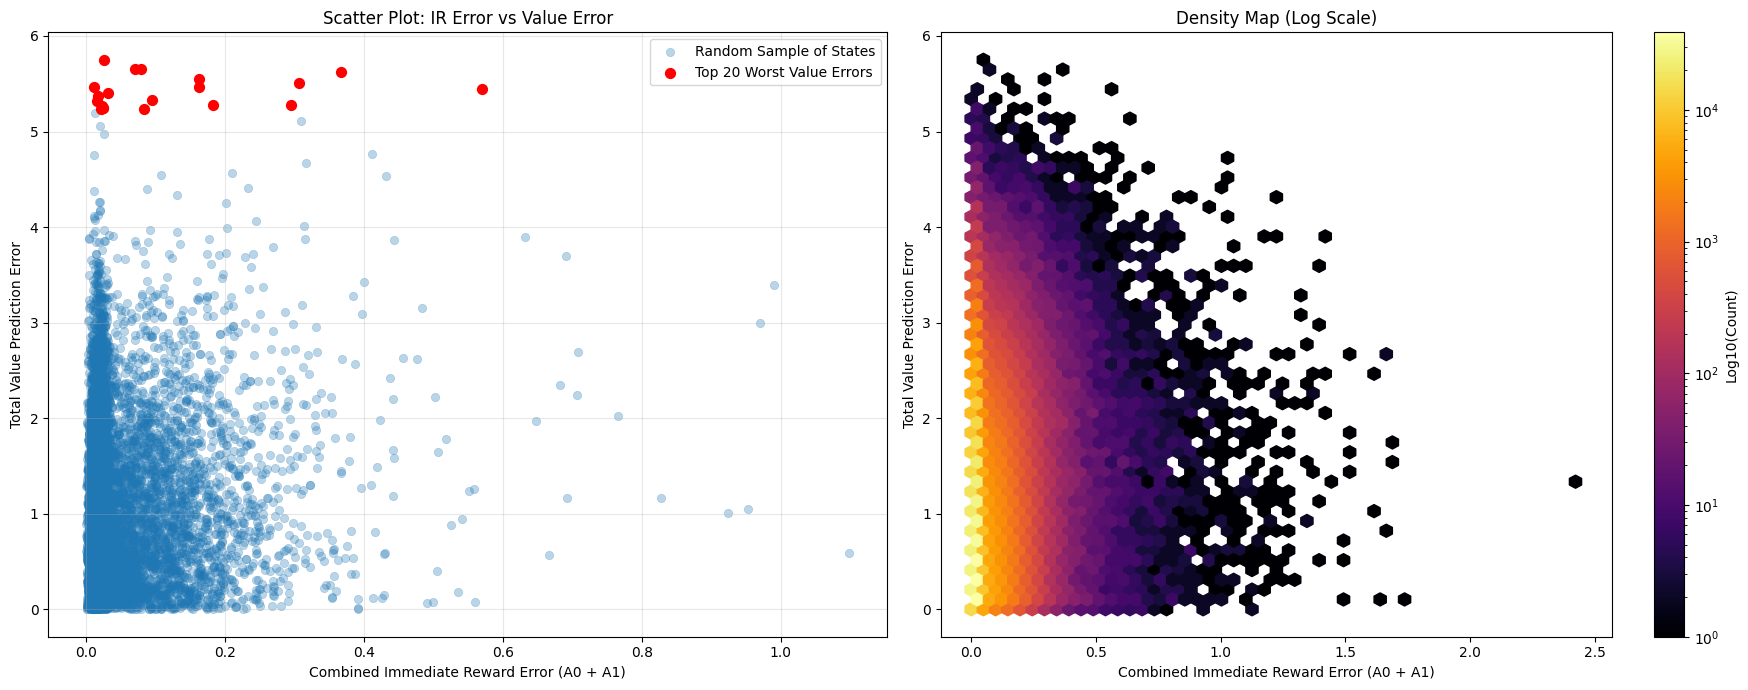

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# --- 1. Prepare Data ---
# Create a metric for Total IR Error (sum of individual errors)
df_combined['sum_ir_error'] = df_combined['error_A0'] + df_combined['error_A1']

# --- 2. Calculate Correlation Coefficients ---
p_corr, _ = pearsonr(df_combined['sum_ir_error'], df_combined['error'])
s_corr, _ = spearmanr(df_combined['sum_ir_error'], df_combined['error'])

print(f"--- Correlation Statistics ---")
print(f"Pearson Correlation (Linear): {p_corr:.4f}")
print(f"Spearman Correlation (Rank):  {s_corr:.4f}")
print(f"Interpretation: A low correlation suggests distinct failure modes.")

# --- 3. Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot A: Scatter Plot with Outliers Highlighted ---
# Sample the data if it's huge to speed up plotting, but keep outliers
df_sample = df_combined.sample(min(10000, len(df_combined)), random_state=42)

sns.scatterplot(
    data=df_sample, 
    x='sum_ir_error', 
    y='error', 
    alpha=0.3, 
    ax=axs[0],
    color='#1f77b4',
    edgecolor=None,
    label='Random Sample of States'
)

# Highlight the Top 20 Worst Value Errors in RED
top_20_worst = df_combined.sort_values(by='error', ascending=False).head(20)
axs[0].scatter(
    top_20_worst['sum_ir_error'], 
    top_20_worst['error'], 
    color='red', 
    s=50, 
    label='Top 20 Worst Value Errors',
    zorder=5
)

axs[0].set_title("Scatter Plot: IR Error vs Value Error")
axs[0].set_xlabel("Combined Immediate Reward Error (A0 + A1)")
axs[0].set_ylabel("Total Value Prediction Error")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# --- Plot B: Density Heatmap (Log Scale) ---
# This shows where the majority of points truly lie
hb = axs[1].hexbin(
    df_combined['sum_ir_error'], 
    df_combined['error'], 
    gridsize=50, 
    cmap='inferno', 
    bins='log', 
    mincnt=1
)
cb = fig.colorbar(hb, ax=axs[1], label='Log10(Count)')
axs[1].set_title("Density Map (Log Scale)")
axs[1].set_xlabel("Combined Immediate Reward Error (A0 + A1)")
axs[1].set_ylabel("Total Value Prediction Error")

plt.tight_layout()
plt.show()